# Домашнее задание № 6

Сегодня мы будем  своими руками реализовывать градиентный бустинг на основе вычисления Lambda! 

В качестве базового алгоритма для бустинга будем использовать ```DecisionTreeRegressor``` из библиотеки ```sklearn```. Как было сказано в лекции, единственное существенное отличие — это целевые метки, на которые обучается каждое дерево: вместо типичных для бустинга ошибок (невязок) используются Lambda-значения. Функцию вычисления лямбд мы рассмотрели на практическом занятии. В решение необходимо осмысленно перенести реализацию в метод ```_compute_lambdas``` класса ```Solution```. 

## Параметры класса
```n_estimators``` — количество деревьев, которые будут строиться в рамках бустинга.

```lr``` — Learning Rate, коэффициент, на который умножаются предсказания каждого нового дерева в алгоритме (каждое дерево учится предсказывать значение lambda, но не факт, что добавление к текущим предсказаниям такого значения даст оптимум, поэтому весь “путь” оптимизации разбивается на маленькие шаги).

```subsample``` — доля объектов от выборки, на которых обучается каждое дерево (доля одинакова для всех деревьев, но сама подвыборка генерируется на каждом шаге отдельно).

```colsample_bytree``` — доля признаков от выборки, на которых обучается каждое дерево (доля одинакова для всех деревьев, но сама подвыборка генерируется на каждом шаге отдельно).

Совокупность двух вышеуказанных параметров позволяет реализовать метод случайных подпространств (смотрите описание по ссылке при необходимости). Понятно, что для применения деревьев (получения предсказания) нужно хранить индексы использованных признаков (но не объектов).

```max_depth``` и ```min_samples_leaf``` — параметры ```DecisionTreeRegressor```, отвечающие за глубину построения дерева и минимальное количество в терминальных (финальных) листьях дерева соответственно. 

## Методы класса
```_get_data```, ```_prepare_data```, ```_scale_features_in_query_groups```, ```_ndcg_k``` уже знакомы — можно перенести их реализацию  с тем лишь отличием, что для удобства срезов по индексам размерности ```ys_train``` и ```ys_test``` должны быть N∗1, где N-количество объектов (без этого грейдер будет отчитываться об ошибке).

```save_model``` и ```load_model``` — методы, отвечающие за сохранение и загрузку модели. Вам необходимо самостоятельно определить набор полей (их минимум 3), которые нужно сохранять после тренировки и загружать для предсказания. После ```load_model``` необходимо добиться, чтобы модель могла давать те же самые предсказания, что и до сохранения. Сохранение и загрузку реализуйте через модуль ```pickle```. Пример:

```bash
state = {…}
f = open(path, 'wb')
pickle.dump(state, f)
```

Предсказания формируются в методе ```predict```. На вход поступает тензор данных размерности N∗D, где N — количество объектов, D — количество признаков. На выходе ожидается применённый алгоритм бустинга, т.е. тензор предсказаний.

Расчёт метрики по набору данных должен производиться методом ```_calc_data_ndcg``` — в нём необходимо проитерироваться по группам запросов, посчитав в каждой ```NDCG```, после чего вернуть усреднённое значение метрики.

## Методы для тренировки
```_train_one_tree``` — метод для тренировки одного дерева. Принимает на вход ```cur_tree_idx``` — номер текущего дерева, который предлагается использовать в качестве random_seed для того, чтобы алгоритм был детерминирован. ```train_preds``` — суммарные предсказания всех предыдущих деревьев (для расчёта лямбд). В рамках метода необходимо рассчитать лямбды для каждой группы в тренировочном наборе данных, затем применить метод случайных подпространств, сделав срез по признакам (случайно выбранная группа, размер которой задан параметром ```colsample_bytree```) и по объектам (тоже случайно выбранная группа, размер зависит от параметра subsample). Затем произвести тренировку одного ```DecisionTreeRegressor```. Возвращаемые значения — это само дерево и индексы признаков, на которых обучалось дерево.

```fit``` — генеральный метод обучения K деревьев, каждое из которых тренируется с использованием метода ```_train_one_tree```. Изначальные предсказания до обучения предлагается приравнять к нулю и от этих значений отталкиваться при обучении первого дерева. Все обученные деревья необходимо сохранить в список, хранящийся в атрибуте trees класса ```Solution```. Для простоты и ускорения работы предлагается рассчитывать предсказания для всех тренировочных и валидационных данных после обучения каждого дерева (но досчитывать только изменения за последнее дерево, храня в памяти предсказания всех предыдущих). Следите за лучшим значением ```NDCG``` (хранить в переменной ```best_ndcg```) — после окончания тренировки нужно обрезать те последние N деревьев, которые лишь ухудшают метрику на валидации. Например, вы обучили 100 деревьев, и лучший результат был достигнут на 78-м. Тогда ```self.trees``` нужно обрезать до 78-го дерева, чтобы модель при предсказании работала лучше всего.

## Критерии оценки
- Корректная предобработка данных.
- Модель адекватно отработала на 1 дереве, ```NDCG``` выше порога случайных предсказаний.
- Модель на 100 деревьев на подложенных данных обучается, ```NDCG≥0.425```.
- Обученная и сохраненная модель после загрузки корректно дала предсказания в методе ```predict```.

In [8]:
import math
import pickle
import random
from typing import List, Tuple
import matplotlib.pyplot as plt

import numpy as np
import torch
from torch import sort
from catboost.datasets import msrank_10k
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [307]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class Solution:
    def __init__(self, n_estimators: int = 100, lr: float = 0.5, ndcg_top_k: int = 10,
                 subsample: float = 0.6, colsample_bytree: float = 0.9,
                 max_depth: int = 5, min_samples_leaf: int = 8):
        self.X_train = None
        self.ys_train = None
        self.X_test = None
        self.ys_test = None
        self._prepare_data()

        self.ndcg_top_k = ndcg_top_k
        self.n_estimators = n_estimators  # количество деревьев
        self.lr = lr  # Learning Rate, коэффициент, на который умножаются предсказания каждого нового дерева
        self.max_depth = max_depth  # максимальная глубина
        self.min_samples_leaf = min_samples_leaf  # минимальное количество термальных листьев

        self.subsample = subsample  # доля объектов от выборки
        self.colsample_bytree = colsample_bytree  # доля признаков от выборки

        self.trees: List[DecisionTreeRegressor] = []  # все деревья
        self.tree_col_id = []
        self.all_ndcg: List[float] = []
        self.best_ndcg = float(0.0)

    def _get_data(self) -> List[np.ndarray]:
        train_df, test_df = msrank_10k()

        X_train = train_df.drop([0, 1], axis=1).values
        y_train = train_df[0].values
        query_ids_train = train_df[1].values.astype(int)

        X_test = test_df.drop([0, 1], axis=1).values
        y_test = test_df[0].values
        query_ids_test = test_df[1].values.astype(int)

        return [X_train, y_train, query_ids_train, X_test, y_test, query_ids_test]
    
    def _scale_features_in_query_groups(self, inp_feat_array: np.ndarray,
                                        inp_query_ids: np.ndarray) -> np.ndarray:
        for id in np.unique(inp_query_ids):
            i = np.where(inp_query_ids == id)
            inp_feat_array[i] = (inp_feat_array[i] - inp_feat_array[i].mean())/inp_feat_array[i].std()
        return torch.from_numpy(inp_feat_array)
    
    def _prepare_data(self) -> None:
        (X_train, y_train, self.query_ids_train,
            X_test, y_test, self.query_ids_test) = self._get_data()

        self.X_train = self._scale_features_in_query_groups(X_train, self.query_ids_train)
        self.ys_train = torch.from_numpy(y_train)

        self.X_test = self._scale_features_in_query_groups(X_test, self.query_ids_test)
        self.ys_test = torch.from_numpy(y_test)


    def _train_one_tree(self, cur_tree_idx: int,
                        train_preds: torch.FloatTensor
                        ) -> Tuple[DecisionTreeRegressor, np.ndarray]:
        """
        Метод для тренировки одного дерева.

        @cur_tree_idx: номер текущего дерева, который предлагается использовать в качестве random_seed для того,
        чтобы алгоритм был детерминирован.
        @train_preds: суммарные предсказания всех предыдущих деревьев (для расчёта лямбд).
        @return: это само дерево и индексы признаков, на которых обучалось дерево
        """
        tree = DecisionTreeRegressor(max_depth = self.max_depth, min_samples_leaf = self.min_samples_leaf, random_state=cur_tree_idx)
        
        queries = torch.arange(self.X_train.shape[1])
        queries, _ = train_test_split(queries, train_size = self.colsample_bytree, random_state=cur_tree_idx)
        queries = queries.sort(descending=False)[0]

        objects = torch.arange(self.X_train.shape[0])
        objects, _ = train_test_split(objects, train_size = self.subsample, random_state=cur_tree_idx)

        #training_x = self.X_train[objects]
        training_x = self.X_train[:, queries]

        lbm = torch.FloatTensor([])
        trn = torch.FloatTensor([])
        for id in np.unique(self.query_ids_train[objects]):
            i = np.where(self.query_ids_train[objects] == id)
            l = self._compute_lambdas(self.ys_train[i], train_preds[i])
            lbm = torch.cat((lbm, l), 0)
            trn = torch.cat((trn, training_x[i]), 0)
        
        tree.fit(trn, lbm)
        
        return tree, queries
    def _calc_data_ndcg(self, queries_list: np.ndarray,
                        true_labels: torch.FloatTensor, preds: torch.FloatTensor) -> float:
        ndcg = []
        for id in np.unique(queries_list):
            i = np.where(queries_list == id)
            ndcg.append(self._ndcg_k(true_labels, preds, self.ndcg_top_k))
        ndcg = np.array(ndcg)
        return ndcg.mean()

    def fit(self):
        """
        генеральный метод обучения K деревьев, каждое из которых тренируется
        с использованием метода _train_one_tree
        """
        set_seed(0)
        # допишите ваш код здесь
        preds = torch.zeros(self.ys_train.shape[0])
        p_list = [0]
        for epoch in tqdm(range(0, self.n_estimators)):
            tree, array = self._train_one_tree(epoch, preds)
            
            self.trees.append(tree)
            self.tree_col_id.append(array)
            
            preds_now = tree.predict(self.X_train[:, array])
            preds-= preds_now*self.lr
            p_list.append(preds)
            
            self.all_ndcg.append(self._calc_data_ndcg(self.query_ids_train, self.ys_train, preds))
        self.all_ndcg = np.array(self.all_ndcg)
        self.best_ndcg = np.max(self.all_ndcg)
        self.trees = self.trees[:np.argmax(self.all_ndcg)]
        #return p_list

    def predict(self, data: torch.FloatTensor) -> torch.FloatTensor:
        pred = torch.zeros(data.shape[0])
        for i in range(len(self.trees)):
            pred-=self.trees[i].predict(data[:, self.tree_col_id[i]])
            
        return pred

    def compute_labels_in_batch(self, y_true):

        # разница релевантностей каждого с каждым объектом
        rel_diff = y_true - y_true.t()

        # 1 в этой матрице - объект более релевантен
        pos_pairs = (rel_diff > 0).type(torch.float32)

        # 1 тут - объект менее релевантен
        neg_pairs = (rel_diff < 0).type(torch.float32)
        Sij = pos_pairs - neg_pairs
        return Sij
    def _compute_lambdas(self, y_true: torch.FloatTensor, y_pred: torch.FloatTensor) -> torch.FloatTensor:
        ys_true_i = y_true.sort(descending=True)[0]
        gain = torch.pow(2, ys_true_i) - 1
        di = torch.sum(gain / torch.log2(torch.arange(2, len(ys_true_i) + 2)))

        ideal_dcg = di
        N = 1 / ideal_dcg
        
        y_true = y_true.reshape(-1, 1)
        y_pred = y_pred.reshape(-1, 1)
        # рассчитаем порядок документов согласно оценкам релевантности
        _, rank_order = torch.sort(y_true, descending=True, axis=0)
        rank_order += 1

        with torch.no_grad():
            # получаем все попарные разницы скоров в батче
            pos_pairs_score_diff = 1.0 + torch.exp((y_pred - y_pred.t()))
            # поставим разметку для пар, 1 если первый документ релевантнее
            # -1 если второй документ релевантнее
            Sij = self.compute_labels_in_batch(y_true)
            # посчитаем изменение gain из-за перестановок
            gain_diff = torch.pow(2.0, y_true) - torch.pow(2.0, y_true.t())

            # посчитаем изменение знаменателей-дискаунтеров
            decay_diff = (1.0 / torch.log2(rank_order + 1.0)) - (1.0 / torch.log2(rank_order.t() + 1.0))
            # посчитаем непосредственное изменение nDCG
            delta_ndcg = torch.abs(N * gain_diff * decay_diff)
            # посчитаем лямбды

            lambda_update =  (0.5 * (1 - Sij) - 1 / pos_pairs_score_diff) * delta_ndcg

            lambda_update = torch.sum(lambda_update, dim=1, keepdim=True)

            
            return lambda_update

    def _ndcg_k(self, ys_true, ys_pred, ndcg_top_k = None) -> float:
        ys_pred_si = ys_pred.sort(descending=True)[1]
        ys_true_si = torch.take(ys_true, ys_pred_si[:ndcg_top_k] if ndcg_top_k != None else ys_pred_si)

        gain = torch.pow(2, ys_true_si) - 1

        d = torch.sum(gain / torch.log2(torch.arange(2, len(ys_true_si) + 2)))
        
        ys_true_i = ys_true.sort(descending=True)[0][:ndcg_top_k] if ndcg_top_k != None else ys_true.sort(descending=True)[0]
        gain = torch.pow(2, ys_true_i) - 1
        di = torch.sum(gain / torch.log2(torch.arange(2, len(ys_true_i) + 2)))
        
        return d/di

    def save_model(self, path: str):
        pickle.dump(self, open(path, "wb"), protocol=2)

    def load_model(self, path: str):
        model = pickle.load(open(path , "rb"))
        self.X_train = model.X_train
        self.ys_train = model.ys_train
        self.X_test = model.X_test
        self.ys_test = model.ys_test

        self.ndcg_top_k = model.ndcg_top_k
        self.n_estimators = model.n_estimators  # количество деревьев
        self.lr = model.lr  # Learning Rate, коэффициент, на который умножаются предсказания каждого нового дерева
        self.max_depth = model.max_depth  # максимальная глубина
        self.min_samples_leaf = model.min_samples_leaf  # минимальное количество термальных листьев

        self.subsample = model.subsample  # доля объектов от выборки
        self.colsample_bytree = model.colsample_bytree  # доля признаков от выборки

        self.trees = model.trees  # все деревья
        self.tree_col_id = model.tree_col_id
        self.all_ndcg = model.all_ndcg
        self.best_ndcg = model.best_ndcg


In [296]:
sol = Solution()
#sol._prepare_data

In [297]:
l = sol.fit()

In [298]:
k = [torch.sum((i-sol.ys_train)**2)**(1/2) for i in l]

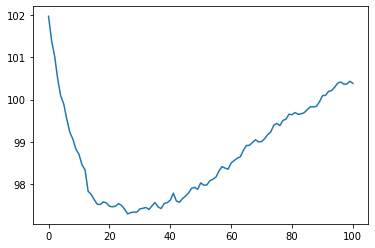

In [299]:
plt.plot(k)

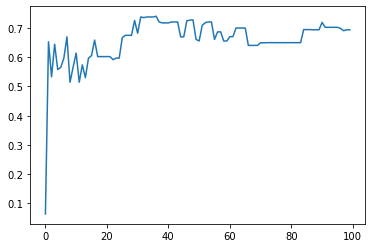

In [300]:
plt.plot(sol.all_ndcg)

In [301]:
k = sol.predict(sol.X_test)

In [302]:
torch.sum((k-sol.ys_test)**2)**(1/2)

tensor(119.5380, dtype=torch.float64)

In [303]:
sol._ndcg_k(sol.ys_test, k)

tensor(0.7779, dtype=torch.float64)

# Запуск и сохранение модели

In [308]:
sol = Solution()
sol.fit()

In [311]:
sol.save_model("model.pckl")

In [312]:
sol1 = Solution()
sol1.load_model("model.pckl")

In [313]:
p = sol1.predict(sol1.X_test)

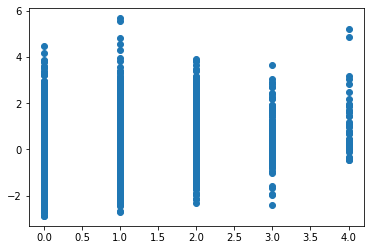

In [316]:
plt.scatter(sol1.ys_test, p)

In [319]:
torch.sum((p-sol1.ys_test)**2)**(1/2)/p.shape[0]

tensor(0.0120, dtype=torch.float64)

In [317]:
sol1._ndcg_k(sol1.ys_test, p)

tensor(0.7779, dtype=torch.float64)